**Portfolio Risk Management using Mean-Variance Optimization and Monte Carlo Simulations**

Any Single prediction about the future is almost certainly wrong. The real world does not deal in averages but operates on distributions, volatility, correlation, and randomness.

A critical part of portfolio optimization is choosing proper weights. There are many techniques out there to do this, for this notebook we will be using Mean-Variance Optimization to calculate portfolio weights.

Monte Carlo Simulations embrace uncertainty. Instead of generating one future, it generates thousands. Thus the result is not a single number, but rather a probability distribution. 

This is how professionals think about risk, not in certanties, but in **probabilities**. 


In [75]:
# Install Packages
%pip install openbb
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [25]:
from openbb import obb
obb.user.preferences.output_type = "dataframe"
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis, t
from datetime import datetime, timedelta
from scipy.optimize import minimize

In [4]:
# Get Data
symbols = ['NVDA', 'MSFT', 'AMZN', 'WMT', 'DVN', 'XOM'] # Portfolio

portfolio_data = obb.equity.price.historical(
    symbol=symbols,
    start_date = "2021-01-01",
    end_date= "2026-01-01",
    auto_adjust = True
)
print(portfolio_data)



                  open        high         low       close     volume  \
date                                                                    
2021-01-04  163.500000  163.600006  157.201004  159.331497   88228000   
2021-01-04   16.000000   16.430000   15.710000   16.129999   10303800   
2021-01-04  222.529999  223.000000  214.809998  217.690002   37130100   
2021-01-04   13.104250   13.652500   12.962500   13.113500  560640000   
2021-01-04   48.099998   48.963333   48.093334   48.843334   32182200   
...                ...         ...         ...         ...        ...   
2025-12-31   36.860001   36.939999   36.459999   36.630001    3917600   
2025-12-31  487.839996  488.140015  483.299988  483.619995   15601600   
2025-12-31  189.570007  190.559998  186.490005  186.500000  120100500   
2025-12-31  111.730003  112.250000  111.320000  111.410004   11487400   
2025-12-31  121.180000  121.260002  119.870003  120.339996   10559900   

            split_ratio  dividend symbol  
date   

In [5]:
# Get Dataset in proper format for calculation
prices = portfolio_data.reset_index().pivot(
    index = 'date',
    columns = 'symbol',
    values = 'close'
)
print(prices.head())

symbol            AMZN        DVN        MSFT      NVDA        WMT        XOM
date                                                                         
2021-01-04  159.331497  16.129999  217.690002  13.11350  48.843334  41.500000
2021-01-05  160.925507  17.360001  217.899994  13.40475  48.583332  43.500000
2021-01-06  156.919006  18.320000  212.250000  12.61450  48.886665  44.610001
2021-01-07  158.108002  18.570000  218.289993  13.34400  48.883331  44.959999
2021-01-08  159.134995  18.110001  219.619995  13.27675  48.876667  45.459999


**Find Optimal Weights using Mean-Variance Optimization**

Steps:
1. Compute Log Returns; log returns are time additive and will be more normally distributed.
2. Estimate mu (expected returns) and sigma (covariance matrix)
3. Solve: min w^T * Sigma * w  s.t.  w^T * mu = target,  sum(w) = 1
4. Find Optimal Weights

In [6]:
# Calculate Log Returns
log_returns = np.log(prices / prices.shift(1)).dropna(how="all")

In [7]:
# Estimate Annual mu and Sigma
TRADING_DAYS = 252

mu = log_returns.mean().values * TRADING_DAYS
sigma = log_returns.cov().values * TRADING_DAYS
N = len(symbols)

print("Mean Five Year Return for Assets in the Portfolio")
for t, m in zip(symbols, mu):
    print(f"{t:6s} {m*100:.2f}%")
print()


Mean Five Year Return for Assets in the Portfolio
NVDA   7.45%
MSFT   16.48%
AMZN   16.04%
WMT    53.35%
DVN    16.57%
XOM    21.39%



In [8]:
# Create Functions for the MVO portfolio
def portfolio_return(w):
    return np.dot(w, mu)

def portfolio_variance(w):
    return np.dot(w, np.dot(sigma, w))

def portfolio_volatility(w):
    return np.sqrt(portfolio_variance(w))


In [9]:
# Find minimum variance portfolio

MIN_WEIGHT = 0.1
MAX_WEIGHT = 0.3

base_constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [[MIN_WEIGHT, MAX_WEIGHT]] * N
w0 = np.ones(N) / N

mv_result = minimize(
    portfolio_variance,
    w0,
    method      = "SLSQP",
    bounds      = bounds,
    constraints = base_constraints,
    options     = {"ftol": 1e-12, "maxiter": 1000}
)

w_mv = mv_result.x
ret_mv = portfolio_return(w_mv)
vol_mv = portfolio_volatility(w_mv)
var_mv = portfolio_variance(w_mv)
 
print("=== MINIMUM VARIANCE PORTFOLIO ===")
print(f"  Expected return : {ret_mv*100:.2f}%")
print(f"  Volatility      : {vol_mv*100:.2f}%")
print(f"  Variance        : {var_mv*100:.4f}%")
print()
print("  Weights:")
for t, w in zip(symbols, w_mv):
    print(f"    {t:6s}  {w*100:.2f}%")


=== MINIMUM VARIANCE PORTFOLIO ===
  Expected return : 20.40%
  Volatility      : 18.81%
  Variance        : 3.5398%

  Weights:
    NVDA    10.00%
    MSFT    10.00%
    AMZN    16.03%
    WMT     10.00%
    DVN     30.00%
    XOM     23.97%


**Monte Carlo Simulation**
"Simulation is useful in estimating the profit and loss distribution of a portfolio and thus in computing risk measures that summarize this distribution" (Glasserman, p.481).
***Monte Carlo Methods in Financial Engineering***


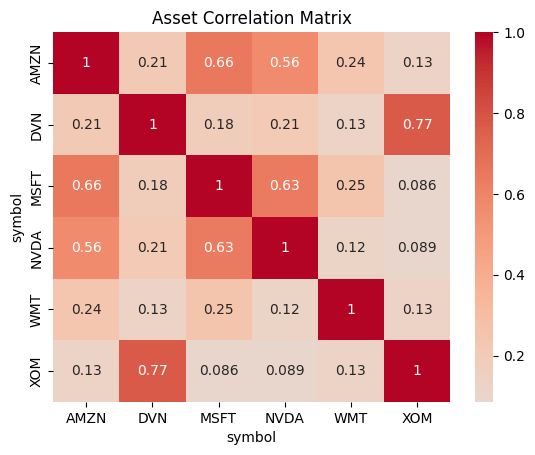

In [14]:
# Correlation Matrix of Assets
correlation_matrix = log_returns.corr()
sns.heatmap(correlation_matrix, annot=True, center=0, cmap="coolwarm")
plt.title("Asset Correlation Matrix")
plt.show()


In [ ]:
portfolio_return = log_returns.dot(w_mv)

In [18]:
cov_matrix = log_returns.cov()
Portfolio_volatility = np.sqrt(np.dot(w_mv.T, np.dot(cov_matrix, w_mv)))

In [20]:
print(f"Expected Daily Return {portfolio_return}")
print(f"Daily Volatility {Portfolio_volatility}")



Expected Daily Return date
2021-01-05    0.020377
2021-01-06    0.000481
2021-01-07    0.014083
2021-01-08    0.001218
2021-01-11    0.008549
                ...   
2025-12-24    0.001297
2025-12-26   -0.000376
2025-12-29    0.004760
2025-12-30    0.000997
2025-12-31   -0.005747
Length: 1254, dtype: float64
Daily Volatility 0.01185186387778653


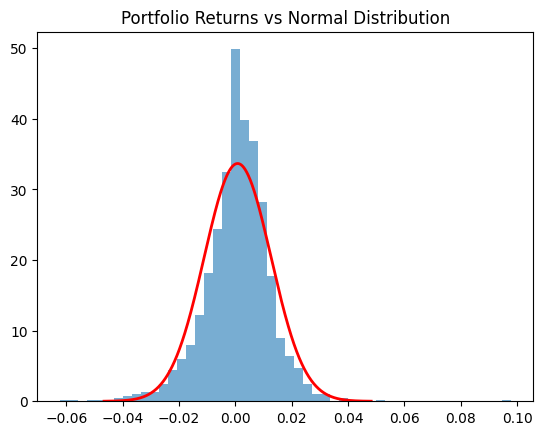

In [21]:
# Distribution of Portfolio Returns
mu = portfolio_return.mean()
sigma = portfolio_return.std()

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

plt.hist(portfolio_return, bins=50, density=True, alpha=0.6)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r', lw=2)

plt.title("Portfolio Returns vs Normal Distribution")
plt.show()

In [23]:
# Diagnose Fat Tails
print("Kurtosis: ", kurtosis(portfolio_return, fisher=False))

Kurtosis:  8.724544405974937


In [ ]:
# Due to fat tails do a student_t distribution
deg_free, loc, scale = t.fit(portfolio_return)
print("deegress of freedom: ", deg_free)
print("loc: ", loc)
print("scale", scale)

"""
Deg_free = tail thickness parameter
loc = mean-like parameter
scale = volatility like parameter
"""

deegress of freedom:  3.992077104120277
loc:  0.0013356242201743847
scale 0.008500798283925352


In [39]:
# Student-t Monte Carlo Simulation
def monte_carlo_student_t(portfolio_return, 
                          initial_value = 10000, 
                          num_days = 252, 
                          num_sims = 10000, 
                          random_state = 42):


    sim_log_returns = t.rvs(
        df = deg_free,
        loc = loc,
        scale = scale,
        size = (num_days, num_sims),
        random_state = random_state
    )

    # Convert Log Returns to portfolio value paths
    portfolio_paths = initial_value * np.exp(
        np.cumsum(sim_log_returns, axis=0)
    )

    ending_values = portfolio_paths[-1]

    return portfolio_paths, ending_values

In [ ]:
portfolio_paths, ending_values = monte_carlo_student_t(
    portfolio_return=portfolio_return,
    initial_value = 10000,
    num_days = 252,
    num_sims= 10000
)


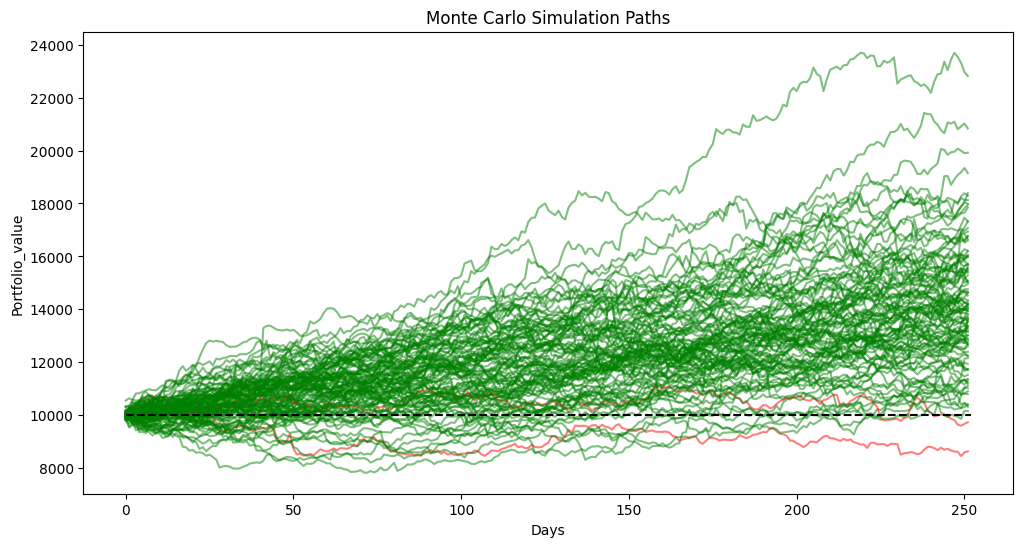

In [51]:
# Plot Portfolio Paths
initial_value = 10000

plt.figure(figsize=(12, 6))
num_paths_to_plot = 100

for i in range(num_paths_to_plot):
    path = portfolio_paths[:, i]

    if path[-1] < initial_value:
        color = "red"
    else:
        color = "green"
    plt.plot(path, color=color, alpha=0.5)

plt.title("Monte Carlo Simulation Paths")
plt.hlines(initial_value, 0, portfolio_paths.shape[0], colors="black", linestyles= "--")
plt.xlabel("Days")
plt.ylabel("Portfolio_value")
plt.show()

In [61]:
# Metrics from Monte Carlo Simulation
print("Final Value Portfolio Statistics")
print("--------------------------------")
print(f"Mean: ${ending_values.mean():,.0f}")
print(f"Median: ${np.median(ending_values):,.0f}")
print(f"Standard Deviation: ${ending_values.std():,.0f}")
print(f"Min: ${ending_values.min():,.0f}")
print(f"Max: ${ending_values.max():,.0f}")

Final Value Portfolio Statistics
--------------------------------
Mean: $14,284
Median: $14,004
Standard Deviation: $2,791
Min: $5,443
Max: $34,076


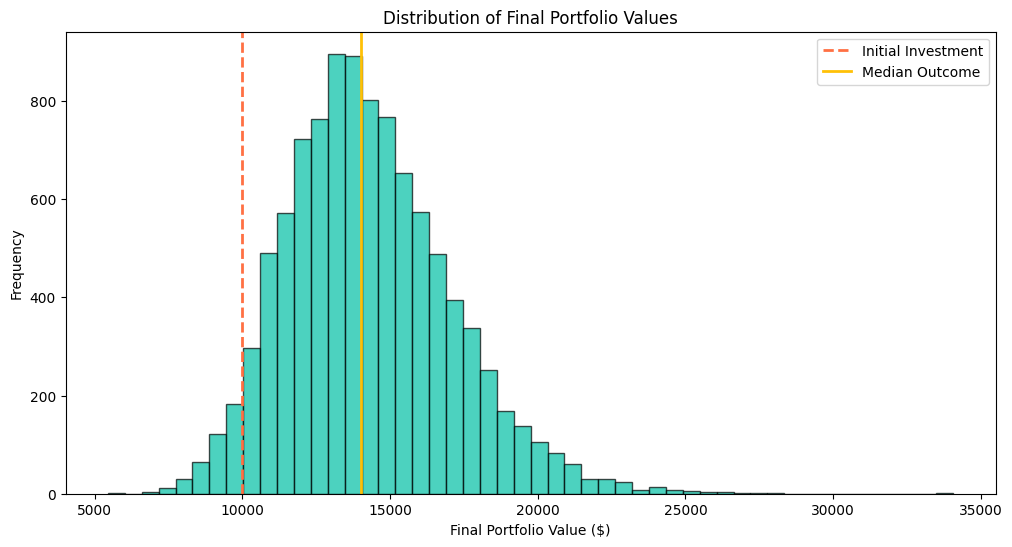

In [64]:
# Distribution of Ending Values
plt.figure(figsize=(12,6))
plt.hist(ending_values, bins=50, alpha=0.7, color='#00BFA5', edgecolor='black')
plt.axvline(x=initial_value, color='#FF7043', linestyle='--', linewidth=2, label='Initial Investment')
plt.axvline(x=np.median(ending_values), color='#FFC107', linestyle='-', linewidth=2, label='Median Outcome')
plt.title('Distribution of Final Portfolio Values')
plt.xlabel('Final Portfolio Value ($)')
plt.ylabel('Frequency')
plt.legend()

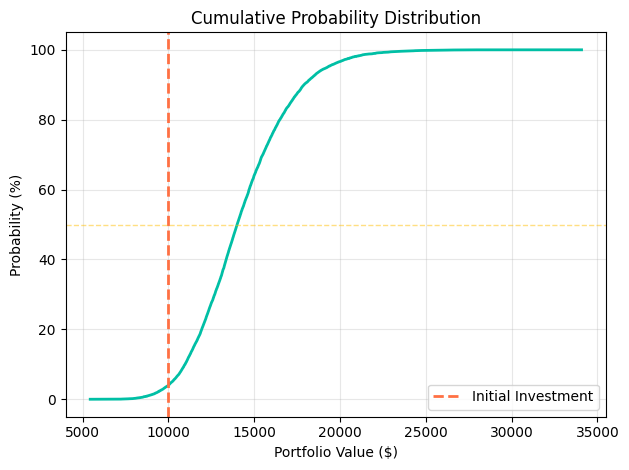

In [65]:
# Cumulative Probability
sorted_values = np.sort(ending_values)
cumulative_prob = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
plt.plot(sorted_values, cumulative_prob * 100, linewidth=2, color='#00BFA5')
plt.axvline(x=initial_value, color='#FF7043', linestyle='--', linewidth=2, label='Initial Investment')
plt.axhline(y=50, color='#FFC107', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Cumulative Probability Distribution')
plt.xlabel('Portfolio Value ($)')
plt.ylabel('Probability (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Var and CvaR
confidence_level = 0.05
var_value = np.percentile(ending_values, confidence_level * 100)
cvar_value = ending_values[ending_values <= var_value].mean()
print(f"Value at Risk (VaR) at {confidence_level*100:.0f}% confidence:")
print(f"  There is a {confidence_level*100:.0f}% chance your portfolio will be worth less than ${var_value:,.0f}")
print(f"Conditional VaR (CVaR):")
print(f"  If things go badly (worst {confidence_level*100:.0f}% of outcomes), average portfolio value: ${cvar_value:,.0f}")
"""

"""

Value at Risk (VaR) at 5% confidence:
  There is a 5% chance your portfolio will be worth less than $10,212
Conditional VaR (CVaR):
  If things go badly (worst 5% of outcomes), average portfolio value: $9,370


In [72]:
# Probability of Profit and Loss
num_simulations = 10000
prob_profit = (ending_values > initial_value).sum() / num_simulations * 100
prob_double = (ending_values > initial_value  * 2).sum() / num_simulations * 100
prob_loss = (ending_values < initial_value).sum() / num_simulations * 100
print(f"\nProbability Analysis:")
print(f"  Probability of any profit: {prob_profit:.1f}%")
print(f"  Probability of doubling investment: {prob_double:.1f}%")
print(f"  Probability of losing money: {prob_loss:.1f}%")


Probability Analysis:
  Probability of any profit: 96.0%
  Probability of doubling investment: 3.4%
  Probability of losing money: 4.0%


Monte Carlo Simulations are a great tool for portfolio risk management becasue it models a wide range of possible future outcomes and captures uncertainty. Monte Carlo allows investors to quantify risk and probabilities of losses better than just a single return or statistic assumption would.